# Trading Book PnL
## Setting Up System Variables

In [266]:
import os 
import sys
import pyarrow
import pandas as pd
import numpy as np
import getpass as _getpass
from datetime import date
user_name = _getpass.getuser()

if user_name=='fabioballoni':
    sys.path.append('/Users/%s/Development/repos/risk/'%user_name)
elif user_name == 'victoriadobryashkina':
    sys.path.append('/Users/victoriadobryashkina/Documents/Coding/repos')

from risk_pylibrary import *

sys.path.append('/Users/victoriadobryashkina/Documents/Coding/repos/risk_pylibrary')
import tools.snowflake_db.db_connection as db

In [267]:
# Custom Modules
#from tools.snowflake_db import db_connection as db
from risk_pylibrary.projects.pnl import pnl_fifo as pnl
from risk_pylibrary.projects.pnl import pnl_support as pnl_sup
reload(pnl)

<module 'risk_pylibrary.projects.pnl.pnl_fifo' from '/Users/victoriadobryashkina/Documents/Coding/repos/risk_pylibrary/projects/pnl/pnl_fifo.py'>

In [268]:
#
#
# #Risk PnL
#
#
acct=9800001601;
syms=['DE000A3E5D64'];
startdate=date(2024,2,7);
enddate=date(2025,5,30);

In [269]:
out_pnl, out_cache, out_pos=pnl.pnl_bt_isin_based(acct,syms,startdate,enddate,verbose=1, use_sb=True)

Initialising ISIN Based Realised PnL Calculation
		 Refetching Trades for 9800001601
9800001601 ['DE000A3E5D64']
9800001601
		 Running Polars PnL Calculation


In [270]:
out_cache.side.unique()

array(['S'], dtype=object)

In [271]:
out_cache

,time,symbol,side,booking_category,booking_type,price,quantity,multiplier
0,2025-05-28 08:52:51.791,DE000A3E5D64,S,TRADING,SELL,44.64,0.516951,1


In [272]:
out_pnl['ddate']=out_pnl['time'].apply(lambda x: x.date())
out_pos['ddate']=out_pos['time'].apply(lambda x: x.date())
out_pos.sort_values(['time']).head()

,time,symbol,trade_price,trade_quantity,short_position,match_quantity,ddate
0,2024-02-09 12:03:22.112,DE000A3E5D64,39.82,1.0,0.0,0.0,2024-02-09
1,2024-02-26 16:08:41.019,DE000A3E5D64,40.84,1.0,0.0,0.0,2024-02-26
2,2024-03-01 22:34:54.280,DE000A3E5D64,40.44,-0.5,0.0,0.5,2024-03-01
3,2024-03-01 22:37:22.976,DE000A3E5D64,40.28,0.5,0.0,0.0,2024-03-01
4,2024-03-06 14:04:21.974,DE000A3E5D64,40.66,1.0,0.0,0.0,2024-03-06


In [273]:
len(out_pnl)

30

In [274]:
out_pnl[out_pnl.ddate>=date(2025,3,31)].groupby('ddate')['pnl'].sum().sort_index()

ddate
2025-03-31    -0.720000
2025-04-02     0.215790
2025-04-03     0.375573
2025-04-04     4.621616
2025-04-11     0.000000
2025-04-22   -12.331096
2025-05-05    -1.525134
2025-05-17     0.214109
2025-05-28    -0.796869
Name: pnl, dtype: float64

In [275]:
#
# 
# TIB_DATA
# 
# 
acct='TIB_DATA';
syms=['DE000A3E5D64'];
startdate=date(2024,2,7);
enddate=date(2025,5,30);

In [276]:

# Custom Modules
#from tools.snowflake_db import db_connection as db
from risk_pylibrary.projects.pnl import pnl_fifo as pnl
from risk_pylibrary.projects.pnl import pnl_support as pnl_sup
reload(pnl)
reload(pnl_sup)

<module 'risk_pylibrary.projects.pnl.pnl_support' from '/Users/victoriadobryashkina/Documents/Coding/repos/risk_pylibrary/projects/pnl/pnl_support.py'>

In [277]:
out_pnl_tib, out_cache_tib, out_pos_tib=pnl.pnl_bt_isin_based(acct,syms,startdate,enddate,verbose=1, use_sb=True)

Initialising ISIN Based Realised PnL Calculation
		 Refetching Trades for TIB_DATA
TIB_DATA ['DE000A3E5D64']
TIB_DATA
		 Running Polars PnL Calculation


In [278]:
out_pnl_tib['ddate']=out_pnl_tib['time'].apply(lambda x: x.date())
out_pos_tib['ddate']=out_pos_tib['time'].apply(lambda x: x.date())
out_pos_tib.sort_values(['time']).head()
out_pnl_tib.head()

,time,symbol,pnl,matched_quantity,ddate
0,2025-03-31 07:48:49.912045,DE000A3E5D64,0.000000,0.000000e+00,2025-03-31
1,2025-03-31 07:48:50.818292,DE000A3E5D64,0.000000,1.000000e+01,2025-03-31
2,2025-03-31 23:59:59.999000,DE000A3E5D64,-0.184427,1.317338e+00,2025-03-31
3,2025-04-01 00:00:00.000000,DE000A3E5D64,0.000000,2.220446e-16,2025-04-01
4,2025-04-01 23:59:59.999000,DE000A3E5D64,0.000000,1.317338e+00,2025-04-01


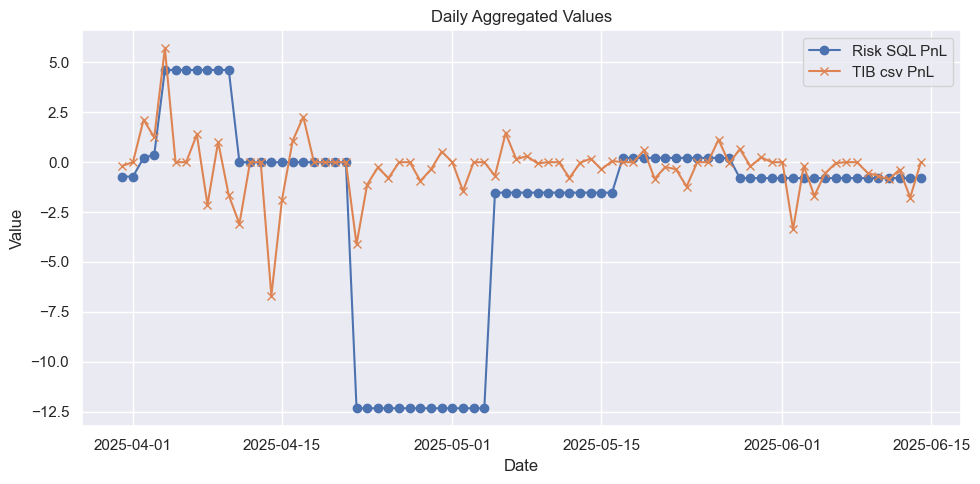

In [292]:
import matplotlib.pyplot as plt

# Aggregate both datasets by date
out_series = out_pnl[out_pnl.ddate>=date(2025,3,31)].groupby('ddate')['pnl'].sum().sort_index()
out_series_tib = out_pnl_tib[out_pnl_tib.ddate>=date(2025,3,31)].groupby('ddate')['pnl'].sum().sort_index()

# Step 2: Create a full union of dates
all_dates = pd.Index(sorted(set(out_series.index).union(out_series_tib.index)))
# Step 3: Reindex and forward-fill
out_series = out_series.reindex(all_dates).ffill()
out_series_tib = out_series_tib.reindex(all_dates).ffill()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(out_series.index, out_series.values, label='Risk SQL PnL', marker='o')
plt.plot(out_series_tib.index, out_series_tib.values, label='TIB csv PnL', marker='x')

plt.title('Daily Aggregated Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


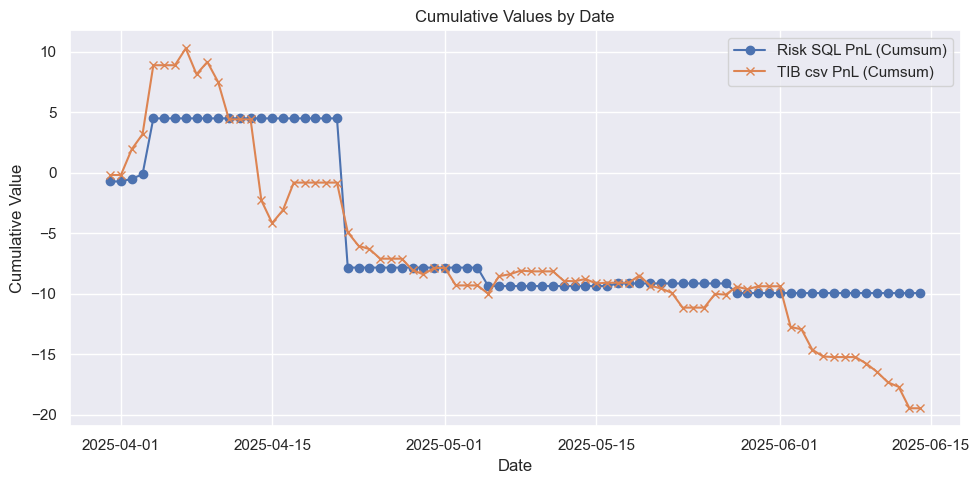

In [291]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date

# Step 1: Create cumulative series
out_series = (
    out_pnl[out_pnl.ddate >= date(2025, 3, 31)]
    .groupby('ddate')['pnl']
    .sum()
    .cumsum()
)

out_series_tib = (
    out_pnl_tib[out_pnl_tib.ddate >= date(2025, 3, 31)]
    .groupby('ddate')['pnl']
    .sum()
    .cumsum()
)

# Step 2: Create a full union of dates
all_dates = pd.Index(sorted(set(out_series.index).union(out_series_tib.index)))

# Step 3: Reindex and forward-fill
out_series = out_series.reindex(all_dates).ffill()
out_series_tib = out_series_tib.reindex(all_dates).ffill()

# Step 4: Plot
plt.figure(figsize=(10, 5))
plt.plot(out_series.index, out_series.values, label='Risk SQL PnL (Cumsum)', marker='o')
plt.plot(out_series_tib.index, out_series_tib.values, label='TIB csv PnL (Cumsum)', marker='x')

plt.title('Cumulative Values by Date')
plt.xlabel('Date')
plt.ylabel('Cumulative Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Check Combined data against csv

In [281]:
syms_sql = "(" + ",".join(f"'{s}'" for s in syms) + ")"
# --- SQL Query ---
qry = f"""
        SELECT 
            tradingaccount,
            convert_timezone('UTC','Europe/Berlin',TO_TIMESTAMP(timestamp/1e9))::timestamp_ntz as time,
            convert_timezone('UTC','Europe/Berlin',TO_TIMESTAMP(timestamp/1e9))::date as booking_date,
            isin AS symbol,
            IFF(notional < 0, 'S', 'B') AS side,
            venue,
            price,
            notional AS quantity
        FROM 
            TIBERIUS_PRD.TRADING_PLATFORM_EXTERNAL_SOURCES.MM_INQUISITOR_ENRICHED_TRADES
        WHERE 
            (convert_timezone('UTC','Europe/Berlin',TO_TIMESTAMP(timestamp/1e9))::date BETWEEN {db.sqldate(startdate)} AND {db.sqldate(enddate)})
            and isin in {syms_sql}
            and tradingaccount=200

    """
df_sql = db.run_query(query=qry)
df_sql["orderType"]= None

df_trades = df_sql

# --- Add derived columns ---
df_trades["booking_type"] = df_trades["side"].map({'B': 'BUY', 'S': 'SELL'})
df_trades["booking_category"] = "TRADING"
df_trades["multiplier"] = 1
df_trades["quantity"]=df_trades["quantity"].abs()
df_trades["signed_quantity"] = np.where(df_trades["side"] == "S", -1 * df_trades["quantity"], df_trades["quantity"])

df_trades["account"] = "TIB_DATA"
df_trades = df_trades[df_trades["tradingaccount"] == 200]

# # Synthetic pair detection (same symbol, quantity, price; close at 23:59:59 → open at 00:00:00)
# df_trades["next_symbol"] = df_trades["symbol"].shift(-1)
# df_trades["next_time"] = df_trades["time"].shift(-1)
# df_trades["next_quantity"] = df_trades["quantity"].shift(-1)
# df_trades["next_price"] = df_trades["price"].shift(-1)
# # Shift side column too
# df_trades["next_side"] = df_trades["side"].shift(-1)

# # Compute time difference
# time_diff = (df_trades["next_time"] - df_trades["time"])

# # Identify synthetic close/open pairs (e.g., 23:59:59 → 00:00:00)
# mask = (
#     (df_trades["symbol"] == df_trades["next_symbol"]) &
#     (
#         (
#         (df_trades["side"] == "S") &
#         (df_trades["next_side"] == "B")
#         ) 
#         #| ##check why can it be B-S
#         #(
#         #(df_trades["side"] == "B") &
#         #(df_trades["next_side"] == "S") 
#         #)
#     )
#     &  # must be opposite
#     (df_trades["quantity"] == df_trades["next_quantity"]) &
#     (df_trades["price"] == df_trades["next_price"]) &
#     (time_diff.dt.total_seconds() > 0) &
#     (time_diff.dt.total_seconds() <= 0.1)  # within 10 ms
# )

# # Drop both timestamps
# timestamps_to_drop = pd.concat([
#     df_trades.loc[mask, "time"],
#     df_trades.loc[mask, "next_time"]
# ])

# df_trades = df_trades[~df_trades["time"].isin(timestamps_to_drop)]

sql_set=df_trades.sort_values(by='time')

In [282]:
sql_set

,tradingaccount,time,booking_date,symbol,side,venue,price,quantity,orderType,booking_type,booking_category,multiplier,signed_quantity,account
105,200,2025-03-31 09:48:49.912045,2025-03-31,DE000A3E5D64,S,TIB,44.18,11.317338,None,SELL,TRADING,1,-11.317338,TIB_DATA
106,200,2025-03-31 09:48:50.818293,2025-03-31,DE000A3E5D64,B,LSX,44.18,10.000000,None,BUY,TRADING,1,10.000000,TIB_DATA
107,200,2025-04-01 01:59:59.999000,2025-04-01,DE000A3E5D64,B,TIB,44.32,1.317338,None,BUY,TRADING,1,1.317338,TIB_DATA
26,200,2025-04-01 02:00:00.000000,2025-04-01,DE000A3E5D64,S,TIB,44.32,1.317338,None,SELL,TRADING,1,-1.317338,TIB_DATA
27,200,2025-04-02 01:59:59.999000,2025-04-02,DE000A3E5D64,B,TIB,44.32,1.317338,None,BUY,TRADING,1,1.317338,TIB_DATA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,200,2025-05-28 08:53:55.072473,2025-05-28,DE000A3E5D64,B,LSX,44.64,109.000000,None,BUY,TRADING,1,109.000000,TIB_DATA
73,200,2025-05-29 01:59:59.999000,2025-05-29,DE000A3E5D64,B,TIB,44.46,1.516951,None,BUY,TRADING,1,1.516951,TIB_DATA
10,200,2025-05-29 02:00:00.000000,2025-05-29,DE000A3E5D64,S,TIB,44.46,1.516951,None,SELL,TRADING,1,-1.516951,TIB_DATA
11,200,2025-05-30 01:59:59.999000,2025-05-30,DE000A3E5D64,B,TIB,44.60,1.516951,None,BUY,TRADING,1,1.516951,TIB_DATA


Csv only

In [283]:
# --- CSV Load ---
df_csv = pd.read_csv("DE000A3E5D64.csv", parse_dates=["timestamp"])
df_csv["time"] = df_csv["timestamp"]
df_csv["booking_date"] = df_csv["timestamp"].dt.date
df_csv["symbol"] = df_csv["isin"]
df_csv["side"] = np.where(df_csv["notional"] < 0, "S", "B")
df_csv["quantity"] = df_csv["notional"].abs()
df_csv = df_csv[[
    "tradingAccount", "time", "booking_date", "symbol", "side", "venue", "price", "quantity", "orderType"
]]

# --- Combine & De-duplicate ---
df_trades = df_csv

# --- Add derived columns ---
df_trades["booking_type"] = df_trades["side"].map({'B': 'BUY', 'S': 'SELL'})
df_trades["booking_category"] = "TRADING"
df_trades["multiplier"] = 1
df_trades["signed_quantity"] = np.where(df_trades["side"] == "S", -1 * df_trades["quantity"], df_trades["quantity"])
df_trades["account"] = "TIB_DATA"
df_trades = df_trades[df_trades["tradingAccount"] == 200]
df_trades.rename(columns={"tradingAccount": "tradingaccount"}, inplace=True)

csv_set=df_trades.sort_values(by='time')


Intersections nad compliments

**SQL HAS +2H**

In [284]:
sql_set["time"] = pd.to_datetime(sql_set["time"]) - pd.Timedelta(hours=2)
csv_set["time"] = pd.to_datetime(csv_set["time"]).dt.round("S")
sql_set["time"] = pd.to_datetime(sql_set["time"]).dt.round("S")



# Define matching key columns including tradingaccount
key_cols = ["tradingaccount","time", "symbol", "side", "price", "quantity"]

# Generate comparison sets
csv_set1 = set(csv_set[key_cols].astype(str).agg("|".join, axis=1))
sql_set1 = set(sql_set[key_cols].astype(str).agg("|".join, axis=1))

# Compare sets
intersection = csv_set1 & sql_set1
csv_only = csv_set1 - sql_set1
sql_only = sql_set1 - csv_set1


In [285]:
csv_set.head()

,tradingaccount,time,booking_date,symbol,side,venue,price,quantity,orderType,booking_type,booking_category,multiplier,signed_quantity,account
260,200,2025-03-31 07:48:50,2025-03-31,DE000A3E5D64,S,TIB,44.18,11.317338,LIMIT,SELL,TRADING,1,-11.317338,TIB_DATA
261,200,2025-03-31 07:48:51,2025-03-31,DE000A3E5D64,B,LSX,44.18,10.000000,MARKET,BUY,TRADING,1,10.000000,TIB_DATA
263,200,2025-04-01 00:00:00,2025-03-31,DE000A3E5D64,B,TIB,44.32,1.317338,MARKET,BUY,TRADING,1,1.317338,TIB_DATA
265,200,2025-04-01 00:00:00,2025-04-01,DE000A3E5D64,S,TIB,44.32,1.317338,MARKET,SELL,TRADING,1,-1.317338,TIB_DATA
268,200,2025-04-02 00:00:00,2025-04-01,DE000A3E5D64,B,TIB,44.32,1.317338,MARKET,BUY,TRADING,1,1.317338,TIB_DATA


In [286]:
sql_set.head()

,tradingaccount,time,booking_date,symbol,side,venue,price,quantity,orderType,booking_type,booking_category,multiplier,signed_quantity,account
105,200,2025-03-31 07:48:50,2025-03-31,DE000A3E5D64,S,TIB,44.18,11.317338,None,SELL,TRADING,1,-11.317338,TIB_DATA
106,200,2025-03-31 07:48:51,2025-03-31,DE000A3E5D64,B,LSX,44.18,10.000000,None,BUY,TRADING,1,10.000000,TIB_DATA
107,200,2025-04-01 00:00:00,2025-04-01,DE000A3E5D64,B,TIB,44.32,1.317338,None,BUY,TRADING,1,1.317338,TIB_DATA
26,200,2025-04-01 00:00:00,2025-04-01,DE000A3E5D64,S,TIB,44.32,1.317338,None,SELL,TRADING,1,-1.317338,TIB_DATA
27,200,2025-04-02 00:00:00,2025-04-02,DE000A3E5D64,B,TIB,44.32,1.317338,None,BUY,TRADING,1,1.317338,TIB_DATA


In [287]:
csv_set["join_key"] = csv_set[key_cols].astype(str).agg("|".join, axis=1)
sql_set["join_key"] = sql_set[key_cols].astype(str).agg("|".join, axis=1)

df_intersection = csv_set[csv_set["join_key"].isin(intersection)].copy()
df_only_csv = csv_set[csv_set["join_key"].isin(csv_only)].copy()
df_only_sql = sql_set[sql_set["join_key"].isin(sql_only)].copy()


In [288]:
print( "len csv: ",len(csv_set))
print( "len sql: ",len(sql_set))
print( "only csv: ",len(df_only_csv))
print( "only sql: ",len(df_only_sql))
print( "intersection: ",len(df_intersection))

len csv:  169
len sql:  136
only csv:  36
only sql:  3
intersection:  133


In [289]:
df_only_sql

,tradingaccount,time,booking_date,symbol,side,venue,price,quantity,orderType,booking_type,booking_category,multiplier,signed_quantity,account,join_key
107,200,2025-04-01,2025-04-01,DE000A3E5D64,B,TIB,44.32,1.317338,None,BUY,TRADING,1,1.317338,TIB_DATA,200|2025-04-01 00:00:00|DE000A3E5D64|B|44.32|1...
41,200,2025-04-03,2025-04-03,DE000A3E5D64,S,TIB,44.12,1.682662,None,SELL,TRADING,1,-1.682662,TIB_DATA,200|2025-04-03 00:00:00|DE000A3E5D64|S|44.12|1...
73,200,2025-05-29,2025-05-29,DE000A3E5D64,B,TIB,44.46,1.516951,None,BUY,TRADING,1,1.516951,TIB_DATA,200|2025-05-29 00:00:00|DE000A3E5D64|B|44.46|1...
